Տնային առաջադրանքը կատարելու վերջնաժամկետը **24.05.2021 15:30** է։ Առաջադրանքները կատարելուց հետո, պետք է 
 
1. ներբեռնեք այս ֆայլը ձեր համակարգիչ (`File` $\to$ `Download .ipynb`)
 
2. ներբեռնեք լրացված ``.py`` ֆայլերը
 
3. վերոնշյալ ֆայլերը ``.zip`` արեք և վերնագրեք հետևյալ ֆորմատով՝ 
    *HW1_AnunAzganunyan.zip* 
 
4. ուղարկեք ֆայլը **fast.1991.ml@gmail.com** հասցեին` նամակի թեմա (subject) դաշտում գրելով **ML1**
 
5. տնայինը կրկին անգամ ուղարկելու դեպքում պատասխանել (reply/ответить) նախորդ նամակին 
 
**Ուշադրություն**․ 
Վերոնշյալ պայմաններին չբավարարելու դեպքում ձեր աշխատանքը չի գնահատվի։

# Basic Linear Classifier

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid') # Plot style

# Some 'magic' so that the notebook will reload external python modules;
# see
# http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

Let's define a synthetic dataset and experiment on it. We will need to define a `pandas` dataframe with 3 columns using the 3 arrays given below.

In [2]:
x1 = np.array([5, 6, 7, 7, 8, 9, 0, 1, 2, 4, 5, 6])
x2 = np.array([2, 1, 3, 5, 10, 3, 4, 8, 6, 10, 9, 11])
y = np.array([1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1])

##### YOUR CODE STARTS HERE##### 
arr = np.array((x1, x2, y))
data = pd.DataFrame(arr.T, columns = ('x1', 'x2','sign'))
##### YOUR CODE ENDS HERE ##### 

Plot the data in axes $x_1$ and $x_2$, highlight two classes with different colors, name the axes.

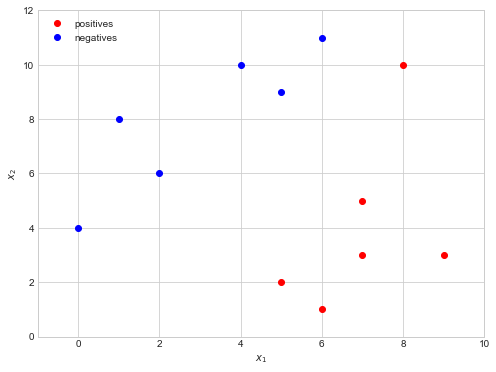

In [3]:
def plot_data(data): 
    plt.figure(figsize=(8, 6))
  ##### YOUR CODE STARTS HERE #####
    
    global data_pos, data_neg
    data_pos = data[data.sign > 0]
    data_neg = data[data.sign < 0]
    plt.plot(data_pos.x1, data_pos.x2, 'ro', label = "positives")
    plt.plot(data_neg.x1, data_neg.x2, 'bo', label = "negatives")
    plt.xlabel('$x_1$')
    plt.ylabel("$x_2$")
    plt.xlim(-1,10)
    plt.ylim(0,12)
    plt.legend(loc = 'upper left')
    
  
  
  ##### YOUR CODE ENDS HERE ##### 

plot_data(data)

Find and highlight in the plot the center of mass for each of the two classes as well as the middle point between these centers.

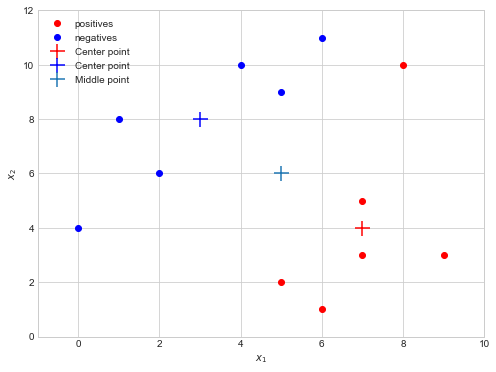

In [4]:
plot_data(data)
##### YOUR CODE STARTS HERE ##### 


mean_pos = data_pos.sum()[0] / len(data_pos) , data_pos.sum()[1]/ len(data_pos) 
mean_neg = data_neg.sum()[0] / len(data_neg) , data_neg.sum()[1] / len(data_neg)
plt.plot(mean_pos[0], mean_pos[1], "r+", markersize = 15,
                                            markeredgewidth = 1.5, label = 'Center point')
plt.plot(mean_neg[0], mean_neg[1], 'b+', markersize = 15,
                                            markeredgewidth = 1.5, label = 'Center point')

plt.plot((mean_pos[0] + mean_neg[0]) / 2, (mean_pos[1] + mean_neg[1]) / 2,'+',  markersize = 15,
                                            markeredgewidth = 1.5,label = 'Middle point' )
plt.legend(loc = 'upper left')
##### YOUR CODE ENDS HERE ##### 
plt.show()

Find the equation of the decision boundary line chosen by the basic linear classifier and add it to the plot. 

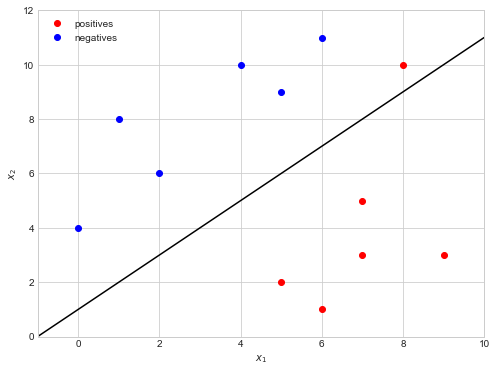

In [5]:
plot_data(data)
##### YOUR CODE STARTS HERE ##### 
x = np.linspace(-1,10,100)
p = np.array(mean_pos)
n = np.array(mean_neg)
w = p - n
t = (p - n) @ (p + n) / 2
plt.plot(x, (t - w[0] * x) / w[1], color = "black")

##### YOUR CODE ENDS HERE ##### 
plt.show()

* Did you notice any misclassified instances? 

* Are the classes linearly separable in the training data? 


# K-nearest neighbours


In this exercise you will program your own KNN algorithm. We will use `Courses 3rd batch/MachineLearning/Labs/Lab_files/Lab1/car.csv` dataset for this. The dataset is from [kaggle](https://www.kaggle.com/elikplim/car-evaluation-data-set).

In [2]:
data = pd.read_csv("car.csv", dtype="category", header = None)
data.columns = ["buying", "maint", "doors", "persons", 
                "lug-boot", "safety", "accept"]

In [3]:
print(data.shape)
data.head()

(1728, 7)


,buying,maint,doors,persons,lug-boot,safety,accept
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


Use the `train_test_split` method (use the documentation) to divide the data into 75% training and 25% testing data. Use parameter random_state = 0 to set the same random seed and ensure that we all get the same results.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data.iloc[:,:-1],
                                                    data['accept'],
                                                    test_size=0.25,
                                                    random_state=0)

In [6]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1296, 6) (432, 6) (1296,) (432,)


In [6]:
def accuracy(actual, predicted):
                                                                                                
  return sum(actual == predicted) / len(predicted)

Upload the `Courses 3rd batch/MachineLearning/Labs/Lab_files/Lab1/knn.py` script to Colab drive and complete the code in order to train a KNN model on the training data and test its performance on the testing data. If you do everything correctly you will get around $75 \%$ accuracy on the test set by running the code below.

In [7]:
%%time
from knn import KNearestNeighbor
model = KNearestNeighbor(X_train, y_train)
predictions = model.fit_predict(X_test, k=1)
accuracy(y_test, predictions)

CPU times: user 342 ms, sys: 2.43 ms, total: 344 ms
Wall time: 343 ms


0.8055555555555556

Now try different values for k, for example $(1,3,...,15)$ and plot the resulting accuracies (on y-axis) with respect to the values of $k$ (on x-axis).

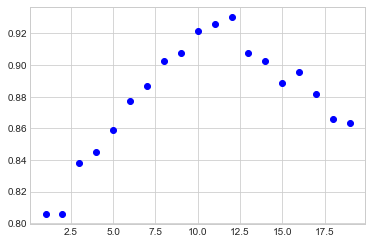

In [8]:
# YOUR CODE HERE

x = range(1,20)
for i in x:
    predictions = model.fit_predict(X_test, k=i)
    plt.plot(i, accuracy(y_test, predictions),'bo');

# Naive Bayes


Now implement your own Naive Bayes method. You can fill in the methods in the prepared class `MyNaiveBayes` in `Courses 3rd batch/MachineLearning/Labs/Lab_files/Lab1/naive_bayes.py` script. Don't worry about the implementation speed at the moment, although, it would be good if you use your experience with Python to come up with an implementation that would also be efficient. Feel free to add methods or change the existing ones, but make sure that the functions `fit` and `predict` will still be in the class. 

If you implement everything correctly, you will get about $82.17\%$ accuracy on the test set without smoothing and $81.25\%$ with Laplace smoothing (don't forget to take into account the number of labels for this dataset).

In [5]:
%%time
from naive_bayes import MyNaiveBayes #takes up to 45 seconds to run 
model = MyNaiveBayes(smoothing=False)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy(predictions, y_test)

Wall time: 24.3 s


0.8217592592592593

In [7]:
%%time
model = MyNaiveBayes(smoothing=True)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy(predictions, y_test)

Wall time: 24.8 s


0.8125